In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import ast

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#convert skill list column into a list
def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)  
    return skill_list  # Return the original NaN value

df['job_skills'] = df['job_skills'].apply(clean_list)

c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Analysis of Data Engineer jobs in India
df_DE_In = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Engineer')].copy()

#drop the none values from the column
df_DE_In = df_DE_In.dropna(subset=['salary_year_avg'])
df_DE_In['salary_year_avg'].sample(10)

156203    147500.0
676969    147500.0
754164    147500.0
660486    155904.5
429745    147500.0
380251    147500.0
750925     96773.0
532079     96773.0
344537    147500.0
492224    155000.0
Name: salary_year_avg, dtype: float64

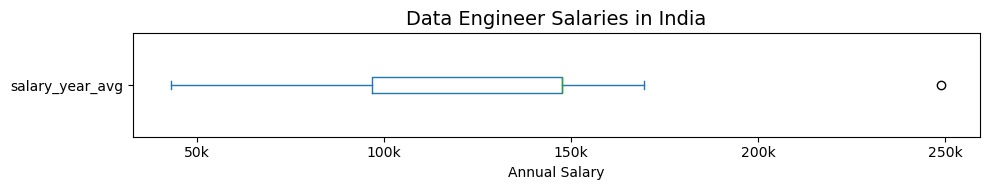

In [13]:
import matplotlib.ticker as ticker

# Create box plot and capture axes
ax = df_DE_In['salary_year_avg'].plot(kind='box', vert=False, figsize=(10, 2))

# Format x-axis with FuncFormatter (show as 20k, 30k, 100k, etc.)
def format_salary(x, pos):
    return f'{x/1000:.0f}k'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# Add title and labels
plt.title('Data Engineer Salaries in India', fontsize=14)
plt.xlabel('Annual Salary')

plt.tight_layout()
plt.show()

Compare different salaries for different jobs using boxplots

C:\Users\Greg\AppData\Local\Temp\ipykernel_5984\1953491585.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(job_list, labels=jobtitles, vert=False)


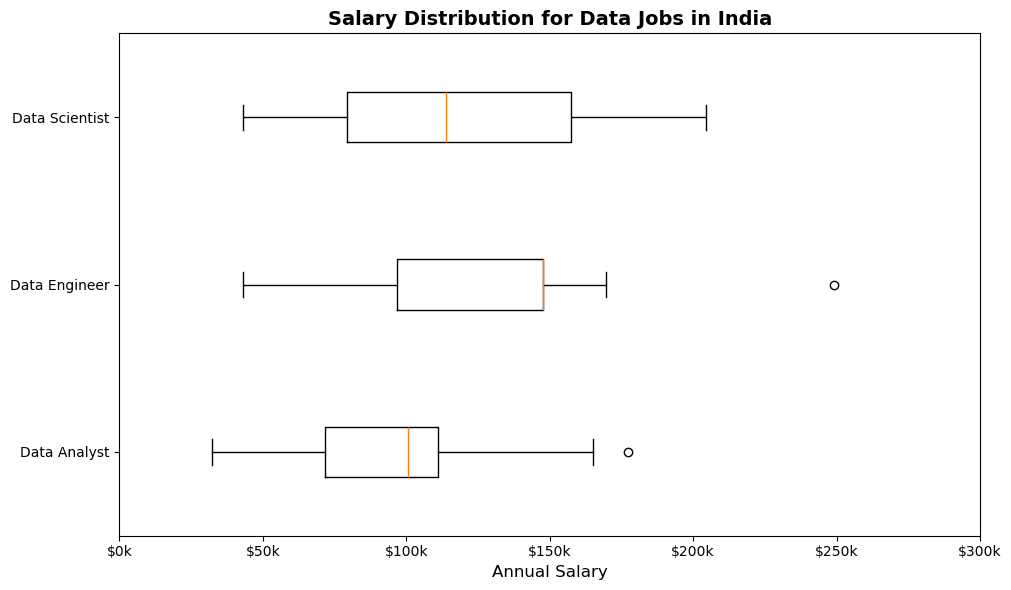

In [27]:
import matplotlib.ticker as ticker

jobtitles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_In = df[(df['job_country'] == 'India') & (df['job_title_short'].isin(jobtitles))].copy()

df_In = df_In.dropna(subset=['salary_year_avg'])

# Create list of salary arrays for each job title 
job_list = [df_In[df_In['job_title_short'] == x]['salary_year_avg'] for x in jobtitles]

# Create boxplot and capture the axes
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(job_list, labels=jobtitles, vert=False)

# Format x-axis with FuncFormatter (show as $20k, $30k, $100k, etc.)
def format_salary(x, pos):
    return f'${x/1000:.0f}k'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# Add title and xlabel
ax.set_title('Salary Distribution for Data Jobs in India', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Salary', fontsize=12)

plt.tight_layout()
plt.xlim(0, 300000)
plt.show()